In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#sklearn
from sklearn.model_selection import train_test_split
#scaler
from sklearn.preprocessing import StandardScaler,OneHotEncoder
#impute 
from sklearn.impute import SimpleImputer
#column transformer
from sklearn.compose import ColumnTransformer
#pipeline
from sklearn.pipeline import Pipeline
# regression model
from sklearn.linear_model import LinearRegression,Ridge
#ensamble model
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
#voting regressor
from sklearn.ensemble import VotingRegressor, StackingRegressor
#metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
#ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
df=pd.read_csv("ModBSP.csv")

In [3]:
df.head(2)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62


In [4]:
#Y data profiling
# !pip install ydata-profiling


In [5]:
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Data Profiling Report for bangladesh students results", explorative=True)
# profile.to_file("ML_bangladesh_students_results.html")

In [6]:
#basic EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2018 non-null   object 
 1   gender        2018 non-null   object 
 2   age           2018 non-null   int64  
 3   address       2018 non-null   object 
 4   famsize       2018 non-null   object 
 5   Pstatus       2018 non-null   object 
 6   M_Edu         2018 non-null   int64  
 7   F_Edu         2018 non-null   int64  
 8   M_Job         2018 non-null   object 
 9   F_Job         2018 non-null   object 
 10  relationship  2018 non-null   object 
 11  smoker        2018 non-null   object 
 12  tuition_fee   2018 non-null   int64  
 13  time_friends  2018 non-null   int64  
 14  ssc_result    2018 non-null   float64
 15  hsc_result    2018 non-null   float64
dtypes: float64(2), int64(5), object(9)
memory usage: 252.4+ KB


In [7]:
#Drop date
if "date" in df.columns:
    df.drop("date", axis=1, inplace=True)


In [8]:
df.columns

Index(['gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu', 'F_Edu',
       'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

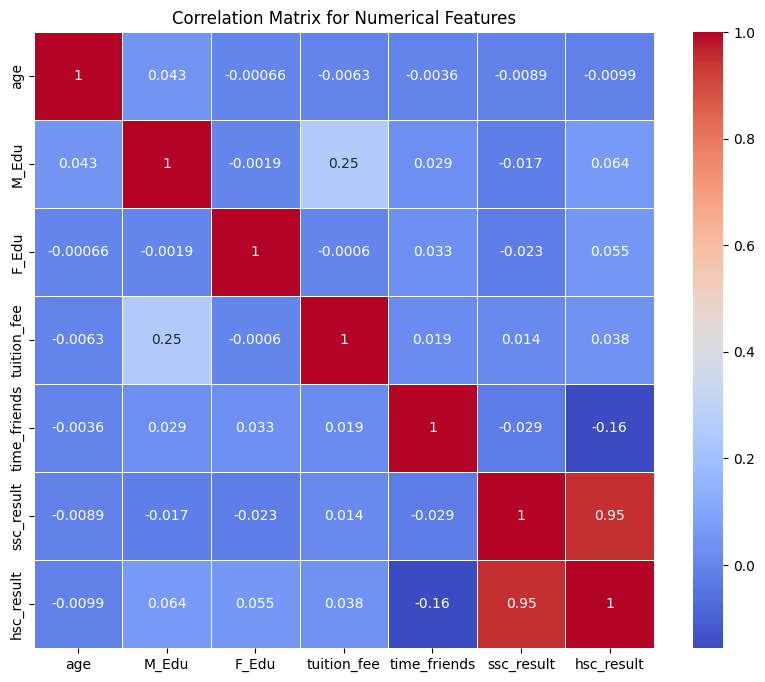

In [9]:
#Correlation for numerical features
numerical_features = df.select_dtypes(include=[np.number]).columns
catagorical_features = df.select_dtypes(include=["object", "category"]).columns
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix for Numerical Features')
plt.show()

In [10]:
corr_target=df.select_dtypes(include=[np.number]).corr()["hsc_result"].sort_values(ascending=False)

In [11]:
corr_target

hsc_result      1.000000
ssc_result      0.950178
M_Edu           0.063776
F_Edu           0.054811
tuition_fee     0.038068
age            -0.009857
time_friends   -0.156356
Name: hsc_result, dtype: float64

In [12]:
# Separate X and y first
X = df.drop("hsc_result", axis=1)
y = df["hsc_result"]

# Build feature lists from X (not df)
numerical_features = X.select_dtypes(include=[np.number]).columns
catagorical_features = X.select_dtypes(include=["object", "category"]).columns

# pipeline for numerical features
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# pipeline for categorical features
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# combine both pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, numerical_features),
        ("cat", cat_transformer, catagorical_features)
    ]
)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
#ensamble boosting stacking
reg_lr=LinearRegression()
reg_rf=RandomForestRegressor(n_estimators=100,random_state=42)
reg_gb=GradientBoostingRegressor(n_estimators=100,random_state=42)

In [14]:
#voting regressor
voting_reg=VotingRegressor(
    estimators=[
        ("lr",reg_lr),("rf",reg_rf),("gb",reg_gb)
        ]
    )

In [15]:
#stacking regressor
stacking_reg=StackingRegressor(
    estimators=[
        ("rf",reg_rf),("gb",reg_gb)
        ],final_estimator=Ridge()
    )

In [16]:
#model training
model_to_train={
    "Linear Regression":reg_lr,
    "Random Forest Regressor":reg_rf,
    "Gradient Boosting Regressor":reg_gb,
    "Voting Ensamble":voting_reg,
    "Stacking Ensamble":stacking_reg
}

In [17]:
model_to_train.items()

dict_items([('Linear Regression', LinearRegression()), ('Random Forest Regressor', RandomForestRegressor(random_state=42)), ('Gradient Boosting Regressor', GradientBoostingRegressor(random_state=42)), ('Voting Ensamble', VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('rf', RandomForestRegressor(random_state=42)),
                            ('gb', GradientBoostingRegressor(random_state=42))])), ('Stacking Ensamble', StackingRegressor(estimators=[('rf', RandomForestRegressor(random_state=42)),
                              ('gb',
                               GradientBoostingRegressor(random_state=42))],
                  final_estimator=Ridge()))])

In [18]:
#training and evaluation
results = []
for model_name, model in model_to_train.items():
    pipe=Pipeline(
        [("preprocessor",preprocessor), 
         ("model", model)])
    #train
    pipe.fit(X_train, y_train)
    #predict
    y_pred=pipe.predict(X_test)
    #evaluate
    mse=mean_squared_error(y_test, y_pred)
    r2=r2_score(y_test, y_pred)
    mae=mean_absolute_error(y_test, y_pred)
    results.append({
        "Model": model_name,
        "MSE": mse,
        "R2 Score": r2,
        "MAE": mae
    })
    results_df=pd.DataFrame(results)
results_df.sort_values(by="R2 Score", ascending=False, inplace=True)
results_df

,Model,MSE,R2 Score,MAE
4,Stacking Ensamble,0.015155,0.959566,0.098696
2,Gradient Boosting Regressor,0.015155,0.959565,0.098902
3,Voting Ensamble,0.015919,0.957528,0.100838
1,Random Forest Regressor,0.018647,0.950248,0.108201
0,Linear Regression,0.020269,0.945920,0.111376


In [19]:
best_model_name=results_df.iloc[0]["Model"]
best_model_name

'Stacking Ensamble'

In [20]:
best_model_object=model_to_train[best_model_name]
best_model_object

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('gb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as th

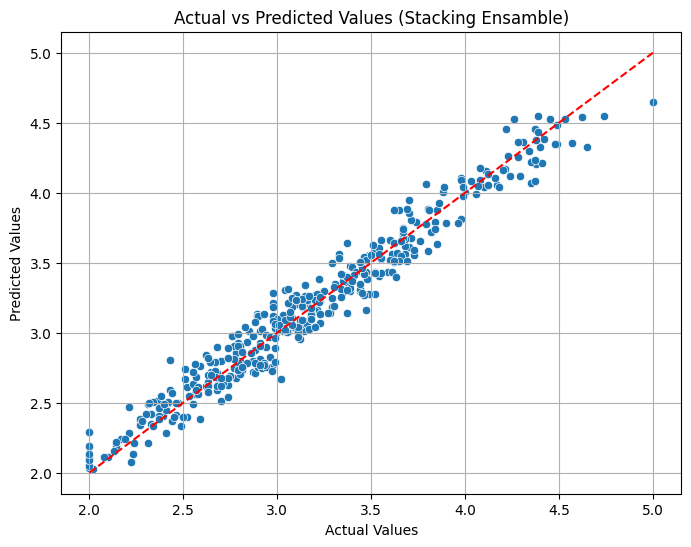

In [21]:
final_pipe=Pipeline(
    [("preprocessor",preprocessor),
        ("model", best_model_object)]
)
final_pipe.fit(X_train, y_train)
y_final_pred=final_pipe.predict(X_test)

#plotting actual vs predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_final_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted Values ({best_model_name})")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Diagonal line
plt.grid(True)
plt.show()

In [22]:
from sklearn.model_selection import cross_val_score

In [23]:
rf_pipe=Pipeline(
    [("preprocessor",preprocessor),
     ("model", RandomForestRegressor(n_estimators=100,random_state=42))]
)

In [24]:
#cross validation
cv_scores=cross_val_score(rf_pipe, X_train, y_train, cv=5, scoring="neg_mean_squared_error")
cv_scores=np.sqrt(-cv_scores)  # Convert to RMSE
cv_scores

array([0.13825617, 0.14202924, 0.15369812, 0.14773708, 0.12940278])

In [25]:
cv_scores.mean()

np.float64(0.14222467953735998)

In [26]:
#std
cv_scores.std()

np.float64(0.00827302663832195)

In [27]:
#stacking ensamble
stacking_pipe=Pipeline([
    ("preprocessor", preprocessor),
    ("model", stacking_reg)
])

In [28]:
#cv for stacking
cv_scores_stacking=cross_val_score(stacking_pipe, X_train, y_train, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
cv_scores_stacking=np.sqrt(-cv_scores_stacking)  # Convert to RMSE
cv_scores_stacking

array([0.12742194, 0.1342731 , 0.13336693, 0.13391606, 0.11927744])

In [29]:
cv_scores_stacking

array([0.12742194, 0.1342731 , 0.13336693, 0.13391606, 0.11927744])

In [30]:
#define grid
param_grid={
    "model__n_estimators":[100,200],
    "model__max_depth":[None,10,20],
    "model__min_samples_split":[2,5]
}

In [31]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

In [32]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [33]:
print(-1*grid_search.best_score_)

0.14145800733122194


In [34]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [35]:
from scipy.stats import randint
my_dist=randint(1,10)
print(my_dist.rvs(5))

[2 8 2 9 5]


In [36]:
param_dist={
    "model__n_estimators":randint(100,500),
    "model__max_depth":[None,10,20],
    "model__min_samples_split":randint(1,10)}

In [37]:
from sklearn.model_selection import RandomizedSearchCV
random_search=RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=1,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [38]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': <scipy.stats....0015010389A90>, 'model__n_estimators': <scipy.stats....00150103887D0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-vali

In [39]:
print("Best Parameters:", random_search.best_params_)
print(-1*random_search.best_score_)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 4, 'model__n_estimators': 448}
0.14084993368592363


In [40]:
import pickle
from sklearn.linear_model import LinearRegression
X_train_lr=[[1],[2],[3],[4],[5]]
y_train_lr=[10,20,30,40,50]
model=LinearRegression()
model.fit(X_train_lr, y_train_lr)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
model.predict([[6]])

array([60.])

In [42]:
filename="ML_final_model.pkl"
with open(filename, "wb") as file:
    pickle.dump(model, file)


In [43]:
#next day
with open("ML_final_model.pkl", "rb") as file:
    loaded_model=pickle.load(file)

In [44]:
loaded_model.predict([[7]])

array([70.])

In [45]:
#Random forest
filename="ML_RF_model.pkl"
with open(filename, "wb") as file:
    pickle.dump(random_search, file)


In [46]:
#load
with open("ML_RF_model.pkl", "rb") as file:
    loaded_rf_model=pickle.load(file)


In [47]:
loaded_rf_model.predict(X_test)

array([3.25358486, 3.65175455, 3.6839633 , 3.93819993, 4.10968009,
       3.27100146, 4.09964785, 2.50801055, 2.10108091, 3.27545334,
       3.57527603, 2.93104246, 3.19883064, 4.50315353, 3.01832587,
       2.63595385, 3.61609093, 3.35818275, 2.87920878, 2.86785921,
       2.76008559, 3.18987175, 2.88704874, 3.23378842, 2.05378079,
       2.64788877, 3.2270904 , 4.03147561, 3.11436372, 4.09647478,
       2.46314233, 3.84002564, 4.50155471, 2.57208642, 3.19078939,
       3.2159185 , 2.75204488, 3.57201338, 2.45261863, 2.60539475,
       2.99196933, 2.96515428, 3.65012611, 2.77703321, 2.32451346,
       3.00689   , 2.61717685, 2.70184354, 4.10520044, 3.21635044,
       2.99176609, 3.40897047, 4.23238369, 3.54569106, 2.98419703,
       3.23721836, 3.26701938, 2.79513402, 3.71203732, 2.70813892,
       3.03779936, 2.65597916, 2.50947728, 4.43437225, 2.58081199,
       3.2271024 , 3.86644784, 2.72599214, 3.06783388, 3.23638222,
       3.01162682, 2.63232789, 2.70175537, 3.43699125, 3.03988

In [48]:
#mlflow
# !pip install mlflow

In [49]:
import mlflow

In [50]:
mlflow.set_tracking_uri("file:///C:/Users/Rahat/Phitron%20ML/mlflow_tracking")
mlflow.set_experiment("test_run")
with mlflow.start_run(run_name="Dummy Run"):
    mlflow.log_metric("Accuracy", 0.95)
    mlflow.log_param("Loss", 0.05)
    #parameter
    mlflow.log_param("model_type", "fake_model_v1")
    mlflow.log_param("Learning Rate", 0.001)

In [51]:
#rf using mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
#mean squared error
from sklearn.metrics import mean_squared_error
#pipeline
from sklearn.pipeline import Pipeline
mlflow.set_experiment("Student Result Prediction with Random Forest")
my_params={
    "n_estimators": 100,
    "max_depth": 10,
    #random state for reproducibility
    "random_state": 42
}
simple_rf_pipeline=Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(**my_params))
])
with mlflow.start_run(run_name="Single_rf"):
    mlflow.log_params(my_params)
    mlflow.log_param("model_type", "Random Forest Regressor")
    #train
    simple_rf_pipeline.fit(X_train, y_train)
    #predict
    y_train_pred=simple_rf_pipeline.predict(X_train)
    train_rmse=np.sqrt(mean_squared_error(y_train, y_train_pred))
    #log train details

    mlflow.log_metric("train_rmse", train_rmse)
    #test
    y_test_pred=simple_rf_pipeline.predict(X_test)
    test_rmse=np.sqrt(mean_squared_error(y_test, y_test_pred))
    mlflow.log_metric("test_rmse", test_rmse)
    #log model



In [52]:
test_rmse

np.float64(0.13592219413742918)